# Diffusion models on 2D toy densities

`probjax.nn.generative.diffusion` implements score/denoising-based generative models: a network is trained to denoise data corrupted at many noise levels, and sampling reverses that corruption with an ODE (probability-flow) or SDE (ancestral/Langevin-style) solver.

This notebook trains `EDM` (the Karras et al. preconditioning + noise schedule, the default recommended setup in `probjax`) on the checkerboard and spiral toy datasets, and compares ODE vs SDE sampling.

In [6]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import EDM

from data import CheckerboardGenerator, SpiralGenerator
from probjax.nn import TimeMLP

In [7]:
datasets = {
    "checkerboard": CheckerboardGenerator(grid_size=3, scale=4.0),
    "spiral": SpiralGenerator(n_turns=3, radius_scale=4.0, noise_std=0.05),
}

## Train

`EDM(net)` wraps `TimeMLP` with the EDM noise schedule and preconditioning, and trains it to predict the clean `x0` from a noisy input at a randomly sampled noise level (`.loss` samples noise levels internally, same recipe as the flow examples: `.fit(rng, data)`).

checkerboard: loss 2.798 -> 2.474 (smoothed)
spiral: loss 2.296 -> 1.868 (smoothed)


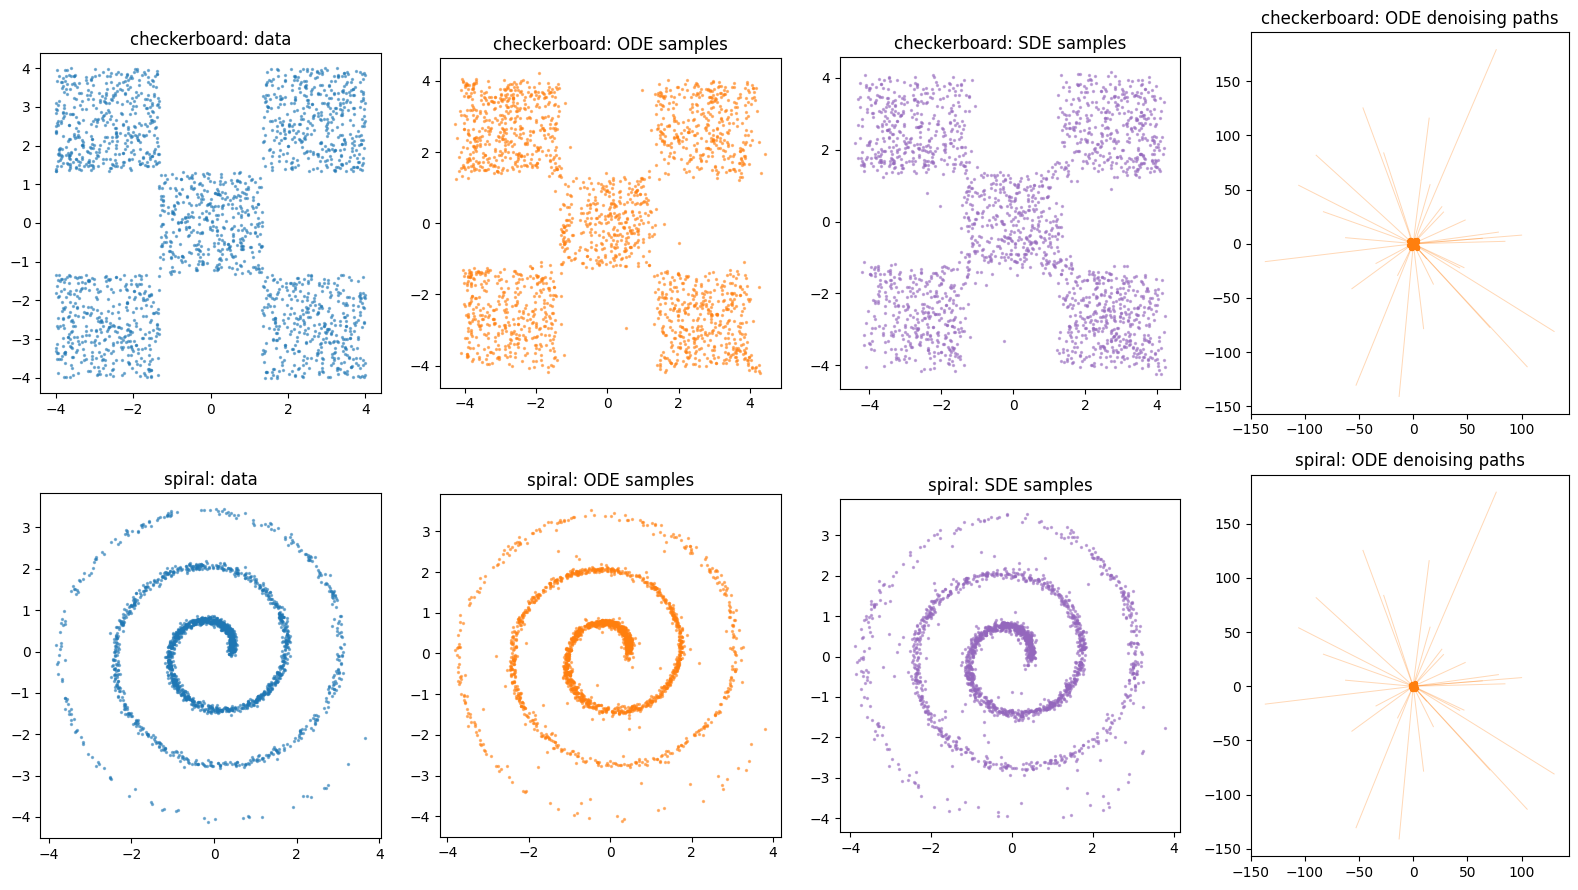

In [8]:
def train_diffusion(data, *, num_steps=20_000, seed=0):
    net = TimeMLP(2, rngs=nnx.Rngs(seed))
    model = EDM(net, num_steps=32)
    losses = model.fit(jax.random.key(seed + 1), data, num_steps=num_steps, batch_size=256)
    return model, losses


fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for row, (name, gen) in zip(axes, datasets.items()):
    data = gen.generate(2000, key=jax.random.key(0))
    model, losses = train_diffusion(data, seed=hash(name) % 1000)
    print(f"{name}: loss {float(losses[:200].mean()):.3f} -> {float(losses[-200:].mean()):.3f} (smoothed)")

    ode_samples = model.as_dist((2,), mode="ode").sample(jax.random.key(0), (2000,))
    sde_samples = model.as_dist((2,), mode="sde").sample(jax.random.key(1), (2000,))

    row[0].scatter(data[:, 0], data[:, 1], s=2, alpha=0.5)
    row[0].set_title(f"{name}: data")
    row[1].scatter(ode_samples[:, 0], ode_samples[:, 1], s=2, alpha=0.5, color="C1")
    row[1].set_title(f"{name}: ODE samples")
    row[2].scatter(sde_samples[:, 0], sde_samples[:, 1], s=2, alpha=0.5, color="C4")
    row[2].set_title(f"{name}: SDE samples")

    # Denoising trajectory: watch a handful of points travel from noise to data.
    trace = model.as_dist((2,), mode="ode").sample_path(jax.random.key(2), (30,))
    for i in range(trace.shape[1]):
        row[3].plot(trace[:, i, 0], trace[:, i, 1], color="C1", alpha=0.3, linewidth=0.7)
    row[3].scatter(trace[-1, :, 0], trace[-1, :, 1], s=8, color="C1")
    row[3].set_title(f"{name}: ODE denoising paths")

    for ax in row:
        ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Other schedules

`probjax.nn.generative.diffusion` also has `VE` (variance-exploding), `VP` (variance-preserving / DDPM-style) and `CosineDM` (bounded cosine log-SNR schedule), all with the same `net`, `.fit`, `.as_dist` recipe as `EDM` above — swap the class to compare noise schedules on the same data.